In [1]:
import pandas as pd
import seaborn as sns

my_folder = "MultislotKartenNerf"

df_all = pd.read_parquet(my_folder + "/History.parquet")
cards = pd.read_pickle(my_folder + "/cards.pkl")
df_all.head(5)


,budget,bau_em,runde,game_id,wae_schu,wae_tech,wp_eff,bedarf,strom_prod,speicher,zufriedenheit,sp,slots,occupied,played_cards,excluded_ids,played_cards_log,round_end_reason,netzbezug
0,8,6,1,0,2,0,-1,0,0,0,7,1,"[-1, -1, -1, -1, 42, -1]",[Lüftung],"[42, 5]",[],"[{'runde': 1, 'card_id': 42}, {'runde': 1, 'ca...",no_playable_drawn_cards,9
1,1,6,2,0,5,4,1,1,0,2,5,3,"[31, -1, 61, -1, 42, 22]","[Lüftung, Wärmeerzeugung, Dachnutzung, Fenster]","[5, 42, 22, 25, 61, 31]",[],"[{'runde': 1, 'card_id': 42}, {'runde': 1, 'ca...",no_playable_drawn_cards,14
2,1,6,3,0,5,4,3,1,0,2,4,7,"[31, -1, 61, 50, 42, 22]","[Abgabe, Lüftung, Wärmeerzeugung, Fenster, Dac...","[5, 42, 50, 22, 25, 61, 31]",[],"[{'runde': 1, 'card_id': 42}, {'runde': 1, 'ca...",no_playable_drawn_cards,12
3,2,5,4,0,8,4,3,1,0,4,3,10,"[31, 56, 61, 50, 42, 22]","[Abgabe, Lüftung, Wärmeerzeugung, Dämmung, Fen...","[5, 42, 50, 22, 56, 25, 60, 61, 31]",[],"[{'runde': 1, 'card_id': 42}, {'runde': 1, 'ca...",no_playable_drawn_cards,14
4,-4,6,1,1,0,4,1,2,0,4,3,7,"[70, -1, -1, 45, -1, -1]","[Wärmeerzeugung, Abgabe]","[5, 70, 45, 25, 60]",[],"[{'runde': 1, 'card_id': 70}, {'runde': 1, 'ca...",no_playable_drawn_cards,8


In [2]:
cards.tail()

,Name,Slot/Stapel,Count,Heizsystem,Kosten,BauEmissionen,Strombedarf,Stromproduktion,Stromspeicher,Wärmeschutz,...,REAL Stromproduktion,REAL Stromspeicher,REAL Wärmeschutz,REAL Wärmepumpen-Effizienz,Voraussetzung Spalte,Voraussetzung Wert,Voraussetzung Wert NICHT,id,prerequisites,exclusions
46,Thermische Solaranlage,Dachnutzung,1,NaN,2,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61,[],[]
47,Wandheizung,Abgabe,1,NaN,2,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64,[],[]
48,Wärmerückgewinnung des Duschwassers,*Effizienz,1,NaN,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,Heizsystem,WP,NaN,66,"[0, 12, 16, 31, 70]",[]
49,Zentrale Lüftungsanlage,Lüftung,1,NaN,2,0,-1,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69,[],[]
50,Zentrale Luftwärmepumpe,Wärmeerzeugung,1,WP,2,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70,[],[]


In [3]:


df = df_all[df_all["runde"]==4]
df.head(3)

,budget,bau_em,runde,game_id,wae_schu,wae_tech,wp_eff,bedarf,strom_prod,speicher,zufriedenheit,sp,slots,occupied,played_cards,excluded_ids,played_cards_log,round_end_reason,netzbezug
3,2,5,4,0,8,4,3,1,0,4,3,10,"[31, 56, 61, 50, 42, 22]","[Abgabe, Lüftung, Wärmeerzeugung, Dämmung, Fen...","[5, 42, 50, 22, 56, 25, 60, 61, 31]",[],"[{'runde': 1, 'card_id': 42}, {'runde': 1, 'ca...",no_playable_drawn_cards,14
7,-16,6,4,1,0,4,1,2,0,4,3,25,"[70, -1, -1, 45, -1, -1]","[Wärmeerzeugung, Abgabe]","[5, 70, 45, 25, 60]",[],"[{'runde': 1, 'card_id': 70}, {'runde': 1, 'ca...",no_playable_drawn_cards,8
11,8,5,4,2,5,1,0,1,2,9,9,12,"[7, 57, 37, 45, 69, 20]","[Abgabe, Dämmung, Wärmeerzeugung, Lüftung, Fen...","[3, 37, 69, 7, 39, 40, 5, 6, 38, 45, 13, 17, 2...",[18],"[{'runde': 1, 'card_id': 57}, {'runde': 1, 'ca...",no_playable_drawn_cards,5


array([[<Axes: title={'center': 'sp'}>]], dtype=object)

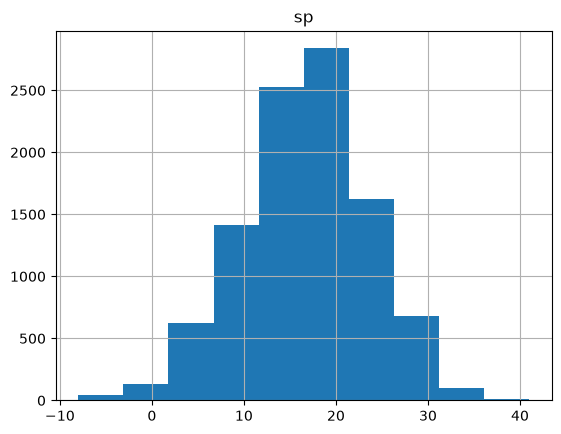

In [4]:
df.hist("sp")

<Axes: xlabel='sp', ylabel='zufriedenheit'>

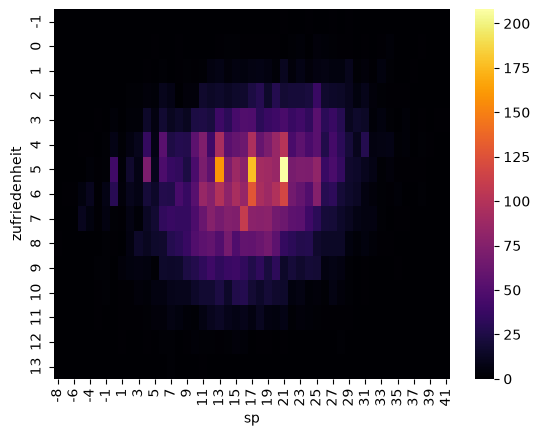

In [5]:
m = pd.crosstab( df['zufriedenheit'], df['sp'])
sns.heatmap(m,  cmap='inferno')

In [6]:
final_games = (
    df
    .loc[df["runde"] == 4]
    .drop_duplicates(subset="game_id")
)

best_percent = (
    final_games
    .nlargest(max(1, round(len(final_games) * 0.01)), "sp")
    .copy()
)
best_percent[["game_id", "sp", "budget"]].head(10)

,game_id,sp,budget
3871,967,41,30
30463,7615,40,7
13331,3332,39,26
1403,350,38,1
8555,2138,38,5
19855,4963,38,32
22339,5584,38,15
27439,6859,38,9
27691,6922,38,16
30999,7749,38,5


In [7]:
slots = cards["Slot/Stapel"].unique()
single_slots = [slot for slot in slots if not slot.startswith("*")]

id_to_name = cards.set_index("id")["Name"].to_dict()
def map_cards(slot_values):
    return {
        slot_name: id_to_name.get(card_id)
        for slot_name, card_id in zip(single_slots, slot_values)
        if card_id >= 0
    }

best_percent["installed_cards"] = best_percent["slots"].apply(map_cards)
best_percent[
    ["game_id", "sp", "budget", "installed_cards"]
].head(20)


,game_id,sp,budget,installed_cards
3871,967,41,30,"{'Dämmung': 'Passivhaussanierung ökologisch',..."
30463,7615,40,7,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...
13331,3332,39,26,"{'Dämmung': 'Passivhaussanierung ökologisch',..."
1403,350,38,1,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...
8555,2138,38,5,"{'Wärmeerzeugung': 'Grundwasser-Wärmepumpe', '..."
19855,4963,38,32,{'Dämmung': 'Ambitionierte Sanierung ökologisc...
22339,5584,38,15,"{'Wärmeerzeugung': 'Zentrale Luftwärmepumpe', ..."
27439,6859,38,9,"{'Wärmeerzeugung': 'Fernwärme-Anschluss', 'Däm..."
27691,6922,38,16,"{'Wärmeerzeugung': 'Fernwärme-Anschluss', 'Däm..."
30999,7749,38,5,{'Wärmeerzeugung': 'Dezentrale Luftwärmepumpe'...


In [8]:
from collections import Counter
card_counts = Counter(
    card_name
    for cards in best_percent["installed_cards"]
    for card_name in cards.values()
)

card_frequency = (
    pd.DataFrame(
        card_counts.items(),
        columns=["Karte", "Anzahl_in_Top_1Prozent"]
    )
    .sort_values("Anzahl_in_Top_1Prozent", ascending=False)
    .reset_index(drop=True)
)

card_frequency["Anteil_Top_100"] = (
    card_frequency["Anzahl_in_Top_1Prozent"] / len(best_percent)
)

card_frequency.head(20)

,Karte,Anzahl_in_Top_1Prozent,Anteil_Top_100
0,Ambitionierte Sanierung ökologisch,42,0.42
1,Niedertemperatur Radiator,36,0.36
2,Grosse Dach-PV-Anlage,34,0.34
3,Mittlere Dach-PV-Anlage,28,0.28
4,Passivhaussanierung ökologisch,25,0.25
5,Tausch der Verglasung,25,0.25
6,Dezentrale Lüftungsgeräte,24,0.24
7,Radiatoren mit Lüftern,23,0.23
8,Lüftungsanlage mit Wärmerückgewinnung,22,0.22
9,Dezentrale Luftwärmepumpe,21,0.21


In [9]:
id_to_name = cards.set_index("id")["Name"].to_dict()

def extract_installed_cards(played_cards_log):
    return [
        id_to_name.get(entry["card_id"], f"Unknown card ID {entry['card_id']}")
        for entry in played_cards_log
    ]

best_percent["all_installed_cards"] = (
    best_percent["played_cards_log"].apply(extract_installed_cards)
)

best_percent[
    ["game_id", "sp", "all_installed_cards"]
].head(20)

,game_id,sp,all_installed_cards
3871,967,41,"[Radiatoren mit Lüftern, LED Beleuchtung, Dach..."
30463,7615,40,"[LED Beleuchtung, Grosse Dach-PV-Anlage, Passi..."
13331,3332,39,"[LED Beleuchtung, PV-Pergola, Flexibles Lastma..."
1403,350,38,"[Kleiner Heimspeicher, Grosse Dach-PV-Anlage, ..."
8555,2138,38,"[Kleine Dach-PV-Anlage, LED Beleuchtung, Gross..."
19855,4963,38,"[Ambitionierte Sanierung ökologisch, Fassadeni..."
22339,5584,38,"[Grosser Batteriespeicher, Mittlere Dach-PV-An..."
27439,6859,38,"[Fernwärme-Anschluss, LED Beleuchtung, Mechani..."
27691,6922,38,"[Grosse Dach-PV-Anlage, Flexibles Lastmanageme..."
30999,7749,38,"[Mittlere Dach-PV-Anlage, LED Beleuchtung, Mec..."


# Häufigkeit aller installierten Karten


In [10]:
all_card_counts = Counter(
    card
    for cards in best_percent["all_installed_cards"]
    for card in cards
)

top_cards = (
    pd.DataFrame(
        all_card_counts.items(),
        columns=["Karte", "Anzahl"]
    )
    .sort_values("Anzahl", ascending=False)
    .reset_index(drop=True)
)

top_cards.head(20)

,Karte,Anzahl
0,Flexibles Lastmanagement,81
1,LED Beleuchtung,75
2,Kleiner Heimspeicher,69
3,E-Herd,69
4,Grosser Batteriespeicher,68
5,Balkonkraftwerk,61
6,Barrierefreier Zugang,49
7,E-Car Lade-Infrastruktur,47
8,Effiziente Haushaltsgeräte,45
9,Thermische Flexibilität,45


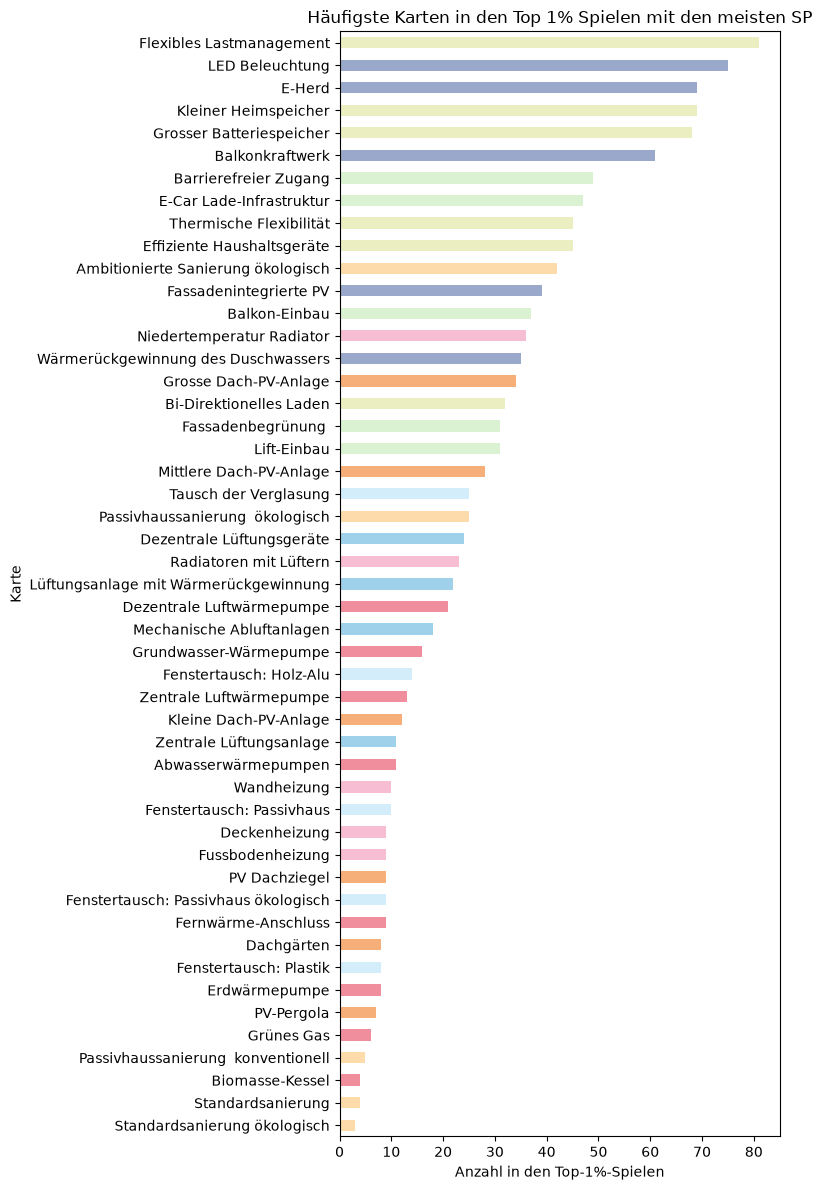

In [12]:
# Slot information hinzufügen
import matplotlib.pyplot as plt
from card_colors import slot_colors, default_color
plot_data = (
    top_cards
    .merge(
        cards[["Name", "Slot/Stapel"]],
        left_on="Karte",
        right_on="Name",
        how="left",
    )
    .drop(columns="Name")
    .sort_values("Anzahl")
)

bar_colors = (
    plot_data["Slot/Stapel"]
    .map(slot_colors)
    .fillna(default_color)
)

ax = plot_data.plot.barh(
    x="Karte",
    y="Anzahl",
    color=bar_colors,
    legend=False,
    figsize=(8, 12),
    title="Häufigste Karten in den Top 1% Spielen mit den meisten SP",
)

ax.set_xlabel("Anzahl in den Top-1%-Spielen")
ax.set_ylabel("Karte")

plt.tight_layout()
plt.show()